In [12]:
import numpy as np
# Step 1: Define the data points
points = np.array([
[2, 10], # A1
[2, 5], # A2
[8, 4], # A3
[5, 8], # A4
[7, 5], # A5
[6, 4], # A6
[1, 2], # A7
[4, 9] # A8
])
# Step 2: Choose initial centroids (e.g., A1, A4, A7 as indexes 0, 3, 6)
centroids = points[[0, 3, 6]]
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))
      
def assign_clusters(points, centroids):
    clusters = []
    for point in points:
        distances = [euclidean_distance(point, centroid) for centroid in centroids]
        cluster = np.argmin(distances)
        clusters.append(cluster)
    return np.array(clusters)

def update_centroids(points, clusters, k):
    new_centroids = []
    for i in range(k):
        cluster_points = points[clusters == i]
        if len(cluster_points) > 0:
            new_centroids.append(np.mean(cluster_points, axis=0))
        else:
            new_centroids.append(points[np.random.randint(0,len(points))])
    return np.array(new_centroids)
# Step 3: Run K-means
k = 3
max_iterations = 100
for i in range(max_iterations):
    clusters = assign_clusters(points, centroids)
    new_centroids = update_centroids(points, clusters, k)
    if np.allclose(centroids, new_centroids):
        break
    centroids = new_centroids
# Step 4: Output results
print("Final Cluster Centers:")
for i,center in enumerate(centroids):
    print(f"C{i+1}=({center[0]:.2},{center[1]:.2f})")
print("\nCluster Assignments:")
for i, cluster in enumerate(clusters):
    print(f"A{i+1} -> Cluster {cluster + 1}")


Final Cluster Centers:
C1=(3.7,9.00)
C2=(7.0,4.33)
C3=(1.5,3.50)

Cluster Assignments:
A1 -> Cluster 1
A2 -> Cluster 3
A3 -> Cluster 2
A4 -> Cluster 1
A5 -> Cluster 2
A6 -> Cluster 2
A7 -> Cluster 3
A8 -> Cluster 1


In [14]:
import math
from collections import Counter

# Dataset
data = [
    {'Outlook': 'Sunny', 'Temp': 'Hot', 'Humidity': 'High', 'Wind': 'Weak', 'PlayTennis': 'No'},
    {'Outlook': 'Sunny', 'Temp': 'Hot', 'Humidity': 'High', 'Wind': 'Strong', 'PlayTennis': 'No'},
    {'Outlook': 'Overcast', 'Temp': 'Hot', 'Humidity': 'High', 'Wind': 'Weak', 'PlayTennis': 'Yes'},
    {'Outlook': 'Rain', 'Temp': 'Mild', 'Humidity': 'High', 'Wind': 'Weak', 'PlayTennis': 'Yes'},
    {'Outlook': 'Rain', 'Temp': 'Cool', 'Humidity': 'Normal', 'Wind': 'Weak', 'PlayTennis': 'Yes'},
    {'Outlook': 'Rain', 'Temp': 'Cool', 'Humidity': 'Normal', 'Wind': 'Strong', 'PlayTennis': 'No'},
    {'Outlook': 'Overcast', 'Temp': 'Cool', 'Humidity': 'Normal', 'Wind': 'Strong', 'PlayTennis': 'Yes'},
    {'Outlook': 'Sunny', 'Temp': 'Mild', 'Humidity': 'High', 'Wind': 'Weak', 'PlayTennis': 'No'},
    {'Outlook': 'Sunny', 'Temp': 'Cool', 'Humidity': 'Normal', 'Wind': 'Weak', 'PlayTennis': 'Yes'},
    {'Outlook': 'Rain', 'Temp': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak', 'PlayTennis': 'Yes'},
    {'Outlook': 'Sunny', 'Temp': 'Mild', 'Humidity': 'Normal', 'Wind': 'Strong', 'PlayTennis': 'Yes'},
    {'Outlook': 'Overcast', 'Temp': 'Mild', 'Humidity': 'High', 'Wind': 'Strong', 'PlayTennis': 'Yes'},
    {'Outlook': 'Overcast', 'Temp': 'Hot', 'Humidity': 'Normal', 'Wind': 'Weak', 'PlayTennis': 'Yes'},
    {'Outlook': 'Rain', 'Temp': 'Mild', 'Humidity': 'High', 'Wind': 'Strong', 'PlayTennis': 'No'},
]

# Helper: entropy calculation
def entropy(subset):
    total = len(subset)
    if total == 0:
        return 0
    counts = Counter([row['PlayTennis'] for row in subset])
    probs = [count / total for count in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p != 0)

# Helper: information gain calculation
def info_gain(data, attr):
    total_entropy = entropy(data)
    total_len = len(data)
    attr_vals = set(row[attr] for row in data)
    subset_entropy = 0.0
    for val in attr_vals:
        subset = [row for row in data if row[attr] == val]
        weight = len(subset) / total_len
        subset_entropy += weight * entropy(subset)
    gain = total_entropy - subset_entropy
    return gain

# Main
print("Entropy of the whole dataset:", round(entropy(data), 3))
attributes = ['Outlook', 'Temp', 'Humidity', 'Wind']
print("\nInformation Gain for each attribute:")
for attr in attributes:
    gain = info_gain(data, attr)
    print(f"{attr}: {round(gain, 3)}")


Entropy of the whole dataset: 0.94

Information Gain for each attribute:
Outlook: 0.247
Temp: 0.029
Humidity: 0.152
Wind: 0.048


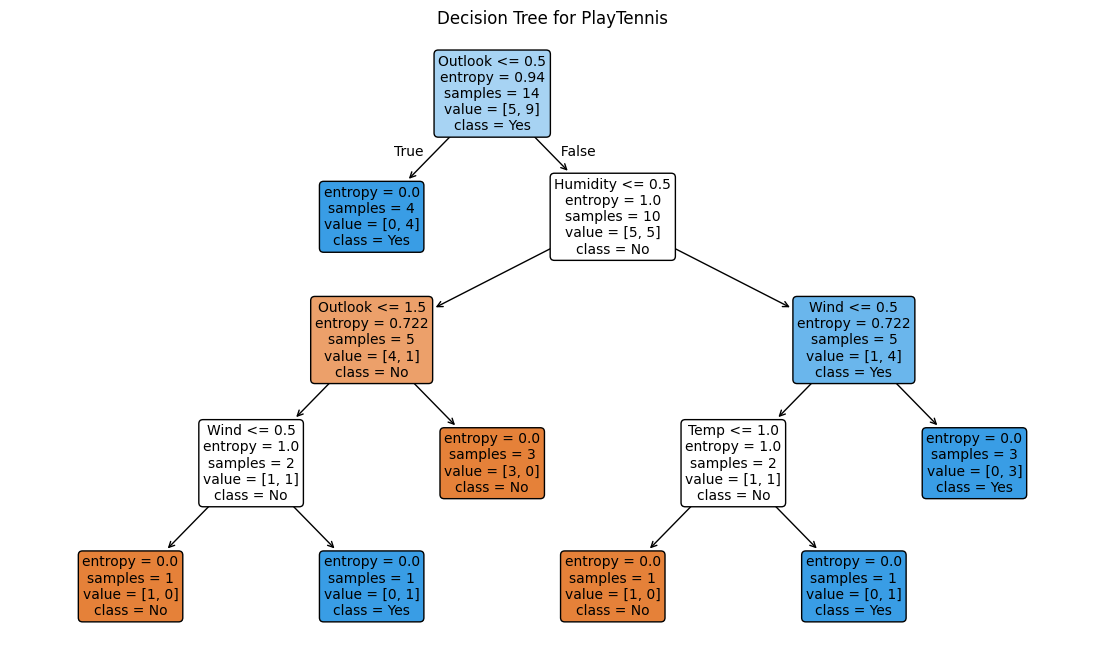

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Step 1: Prepare the data
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
             'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

# Step 2: Encode categorical data
le_dict = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    le_dict[column] = le  # Save encoders in case we want to decode later

# Step 3: Train the Decision Tree
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']
clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
clf.fit(X, y)

# Step 4: Plot the decision tree using matplotlib
plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=X.columns, class_names=le_dict['PlayTennis'].classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree for PlayTennis")
plt.show()


In [21]:
import pandas as pd
import numpy as np

# Step 1: Dataset
data = {
    'Sepal Length': [5.3, 5.1, 7.2, 5.4, 5.1, 5.4, 7.4, 6.1, 7.3, 6.0, 5.8, 6.3, 5.1, 6.3, 5.5],
    'Sepal Width': [3.7, 3.8, 3.0, 3.4, 3.3, 3.9, 2.8, 2.8, 2.9, 2.7, 2.8, 2.3, 2.5, 2.5, 2.4],
    'Species': ['Setosa', 'Setosa', 'Virginica', 'Setosa', 'Setosa', 'Setosa',
                'Virginica', 'Versicolor', 'Virginica', 'Versicolor', 'Virginica',
                'Versicolor', 'Versicolor', 'Versicolor', 'Versicolor']
}

df = pd.DataFrame(data)

# Step 2: Unknown point
unknown = [5.2, 3.1]

# Step 3: Compute Euclidean Distance
df['Distance'] = np.sqrt((df['Sepal Length'] - unknown[0])**2 + (df['Sepal Width'] - unknown[1])**2)

# Step 4: Rank based on distance
df['Rank'] = df['Distance'].rank(method='min').astype(int)

# Step 5: Sort by Distance
df_sorted = df.sort_values('Distance').reset_index(drop=True)

# Step 6: Print table
print("\nFinal Table:\n")
print(df_sorted[['Sepal Length', 'Sepal Width', 'Species', 'Distance', 'Rank']])

# Step 7: Predict using KNN manually
def knn_predict(k):
    top_k = df_sorted.head(k)
    prediction = top_k['Species'].mode()[0]
    return prediction

# Try for k = 1, 2, 3
print("\nPredictions:")
for k in [1, 2, 3]:
    print(f"If k = {k} → Predicted Species: {knn_predict(k)}")



Final Table:

    Sepal Length  Sepal Width     Species  Distance  Rank
0            5.1          3.3      Setosa  0.223607     1
1            5.4          3.4      Setosa  0.360555     2
2            5.3          3.7      Setosa  0.608276     3
3            5.1          2.5  Versicolor  0.608276     4
4            5.8          2.8   Virginica  0.670820     5
5            5.1          3.8      Setosa  0.707107     6
6            5.5          2.4  Versicolor  0.761577     7
7            5.4          3.9      Setosa  0.824621     8
8            6.0          2.7  Versicolor  0.894427     9
9            6.1          2.8  Versicolor  0.948683    10
10           6.3          2.5  Versicolor  1.252996    11
11           6.3          2.3  Versicolor  1.360147    12
12           7.2          3.0   Virginica  2.002498    13
13           7.3          2.9   Virginica  2.109502    14
14           7.4          2.8   Virginica  2.220360    15

Predictions:
If k = 1 → Predicted Species: Setosa
If k =